In [2]:
import torch                                          # Import PyTorch, a deep learning framework
import torch.nn as nn                                 # Import PyTorch's neural network module
import torch.optim as optim                           # Import PyTorch's optimization module
from torch.utils.data import DataLoader, TensorDataset  # Import utilities for creating data loaders and datasets
from tqdm import tqdm                                 # Import tqdm for progress visualization
import numpy as np                                    # Import NumPy, a library for numerical operations
import matplotlib.pyplot as plt                       # Import Matplotlib for plotting

In [3]:
x_val = np.linspace(-10, 10, 1000)
x_train1 = np.linspace(-10, 10, 2500)
x_train2 = np.linspace(-10, 10, 5000)
x_train3 = np.linspace(-10, 10, 10000)

y_val = np.sin(2 * x_val) + np.sin(x_val)
y_train1 = np.sin(2 * x_train1) + np.sin(x_train1)
y_train2 = np.sin(2 * x_train2) + np.sin(x_train2)

x_val_tensor = torch.Tensor(x_val).unsqueeze(1)
x_train_tensor1 = torch.Tensor(x_train1).unsqueeze(1)
y_train_tensor1 = torch.Tensor(y_train1).unsqueeze(1)

x_train_tensor2 = torch.Tensor(x_train2).unsqueeze(1)
y_train_tensor2 = torch.Tensor(y_train2).unsqueeze(1)

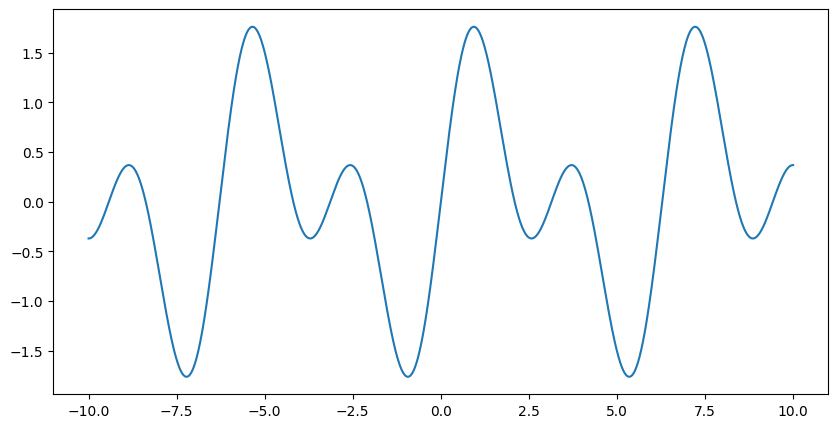

In [4]:
# Plotting the data
plt.figure(figsize=(10, 5))
plt.plot(x_train1, y_train1)
plt.show()

In [ ]:
# model - a lot of changes
class SinActivation(nn.Module): # Made it into a class to easily change the activation function on SineNet
    def forward(self, x):
        return torch.sin(x)

class SineNet(nn.Module):
    def __init__(self):
        super(SineNet, self).__init__()
        self.hidden1 = nn.Linear(1, 128) # A bit overkill but why not
        self.hidden2 = nn.Linear(128, 128)
        self.hidden3 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)
        self.sin = SinActivation()
        # self.tanh = nn.Tanh() # Better than all of them but Sin activation function outperfoms it by a lot
        # self.silu = nn.SiLU() # Better than ReLu, but much worse than Tanh
        
    def forward(self, x):
        x = self.sin(self.hidden1(x))
        x = self.sin(self.hidden2(x))
        x = self.sin(self.hidden3(x))
        x = self.output(x)
        return x

# Instantiate the model (from class create an object)
model = SineNet()

In [ ]:
# hypers and dataloader - slight changes
dataset = TensorDataset(x_train_tensor2, y_train_tensor2) # Turn it into a dataset
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Loss Functions
# loss_function = nn.L1Loss() # L2 Loss was around 120% better
loss_function = nn.MSELoss() # L2 loss

# opt
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100)

In [7]:
def train_model(model, epochs, dataloader, optimizer, scheduler, loss_function):
    losses = []  # Store losses from each epoch for visualization purposes
    best_loss = float('inf')
    best_model_state = None

    for epoch in tqdm(range(epochs), desc="Epochs", ascii=True):
        model.train()
        
        batch_losses = []
        for batch_x, batch_y in dataloader:
            # Forward pass
            outputs = model(batch_x)
            loss = loss_function(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            batch_losses.append(loss.item())
        
        epoch_loss = np.mean(batch_losses)
        losses.append(epoch_loss)

        # Save the best model state
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_model_state = model.state_dict()
            
        # Step the scheduler to adjust the learning rate
        scheduler.step(epoch_loss)
        
        # Print the current learning rate
        current_lr = scheduler.get_last_lr()[0]
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.8f}, Learning Rate: {current_lr:.8f}')

    # Load the best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Best loss: {best_loss:.8f}")

    return model, optimizer, scheduler, losses

In [8]:
# Training loop
epochs = 1000
model, optimizer, scheduler, losses = train_model(model, epochs, dataloader, optimizer, scheduler, loss_function)

Epochs:  10%|#         | 101/1000 [00:16<02:46,  5.41it/s]

Epoch [100/1000], Loss: 0.00012267, Learning Rate: 0.00100000


Epochs:  20%|##        | 201/1000 [00:31<01:50,  7.22it/s]

Epoch [200/1000], Loss: 0.00011400, Learning Rate: 0.00100000


Epochs:  30%|###       | 301/1000 [00:46<01:39,  7.02it/s]

...

Epoch [800/1000], Loss: 0.00001687, Learning Rate: 0.00050000


Epochs:  90%|######### | 901/1000 [02:14<00:13,  7.28it/s]

Epoch [900/1000], Loss: 0.00000016, Learning Rate: 0.00025000


Epochs: 100%|##########| 1000/1000 [02:28<00:00,  6.72it/s]

Epoch [1000/1000], Loss: 0.00000007, Learning Rate: 0.00012500
Best loss: 0.00000007


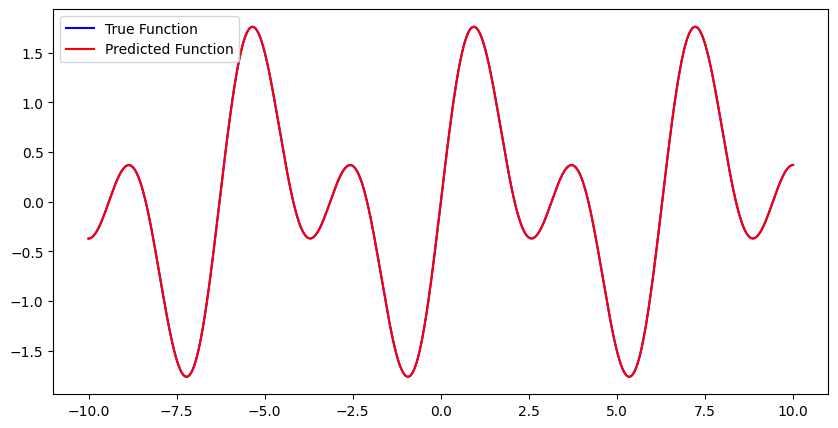

In [9]:
model.eval()
with torch.no_grad():
    predicted = model(x_val_tensor).numpy()

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(x_val, y_val, label='True Function', color='blue')
plt.plot(x_val, predicted, label='Predicted Function', color='red')
plt.legend()
plt.show()